In [ ]:
import re
from pathlib import Path
import pandas as pd

log_path = Path(r"smoothing-48500580.out")
text = log_path.read_text(encoding="utf-8")

pattern = re.compile(
    r"\[(\d+)/500\]\s+idx=(\d+)\s+true=(.+?)\s{2}orig=(.+?)\s{2}"
    r"manifold=(.+?)\((\d+)/100\)\s{2}gauss=(.+?)\((\d+)/100\)\s{2}"
    r"m_stable=(True|False)\s{2}g_stable=(True|False)"
)

rows = []
for m in pattern.finditer(text):
    rows.append({
        "num": int(m.group(1)),
        "idx": int(m.group(2)),
        "true_class": m.group(3).strip(),
        "orig_pred": m.group(4).strip(),
        "manifold_pred": m.group(5).strip(),
        "manifold_votes": int(m.group(6)),
        "gauss_pred": m.group(7).strip(),
        "gauss_votes": int(m.group(8)),
        "m_stable": m.group(9) == "True",
        "g_stable": m.group(10) == "True",
    })

df = pd.DataFrame(rows)
print(f"Parsed {len(df)} / 500 results")
df.head()

Parsed 500 / 500 results


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes,gauss_pred,gauss_votes,m_stable,g_stable
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68,"unicycle, monocycle",35,False,True
1,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52,wire-haired fox terrier,13,True,False
2,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66,sturgeon,19,False,False
3,4,12447,"Eskimo dog, husky","dingo, warrigal, warragal, Canis dingo","timber wolf, grey wolf, gray wolf, Canis lupus",36,"timber wolf, grey wolf, gray wolf, Canis lupus",11,False,False
4,5,39489,shoji,shoji,chest,25,shoji,16,False,True


In [ ]:
# === Summary Statistics ===
n = len(df)
m_stable = df["m_stable"].sum()
g_stable = df["g_stable"].sum()

# Orig accuracy (orig_pred == true_class)
df["orig_correct"] = df["orig_pred"] == df["true_class"]
df["manifold_correct"] = df["manifold_pred"] == df["true_class"]
df["gauss_correct"] = df["gauss_pred"] == df["true_class"]

# Manifold preserves original prediction
df["manifold_preserves_orig"] = df["manifold_pred"] == df["orig_pred"]
df["gauss_preserves_orig"] = df["gauss_pred"] == df["orig_pred"]

summary = pd.DataFrame({
    "Metric": [
        "Total images",
        "Certified stable",
        "Certified stable (%)",
        "Mean top-class votes",
        "Median top-class votes",
        "Preserves orig pred",
        "Preserves orig pred (%)",
        "Correct (matches true label)",
    ],
    "Manifold Smoothing": [
        n,
        int(m_stable),
        f"{m_stable/n*100:.1f}%",
        f"{df['manifold_votes'].mean():.1f}",
        f"{df['manifold_votes'].median():.0f}",
        int(df['manifold_preserves_orig'].sum()),
        f"{df['manifold_preserves_orig'].mean()*100:.1f}%",
        f"{df['manifold_correct'].sum()} ({df['manifold_correct'].mean()*100:.1f}%)",
    ],
    "Gaussian (Isotropic)": [
        n,
        int(g_stable),
        f"{g_stable/n*100:.1f}%",
        f"{df['gauss_votes'].mean():.1f}",
        f"{df['gauss_votes'].median():.0f}",
        int(df['gauss_preserves_orig'].sum()),
        f"{df['gauss_preserves_orig'].mean()*100:.1f}%",
        f"{df['gauss_correct'].sum()} ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
})

print("Original model accuracy on these 500 images:", f"{df['orig_correct'].mean()*100:.1f}%")
print()
summary.style.hide(axis='index')

Original model accuracy on these 500 images: 68.8%



Metric,Manifold Smoothing,Gaussian (Isotropic)
Total images,500,500
Certified stable,396,407
Certified stable (%),79.2%,81.4%
Mean top-class votes,72.1,27.4
Median top-class votes,75,23
Preserves orig pred,396,407
Preserves orig pred (%),79.2%,81.4%
Correct (matches true label),324 (64.8%),327 (65.4%)


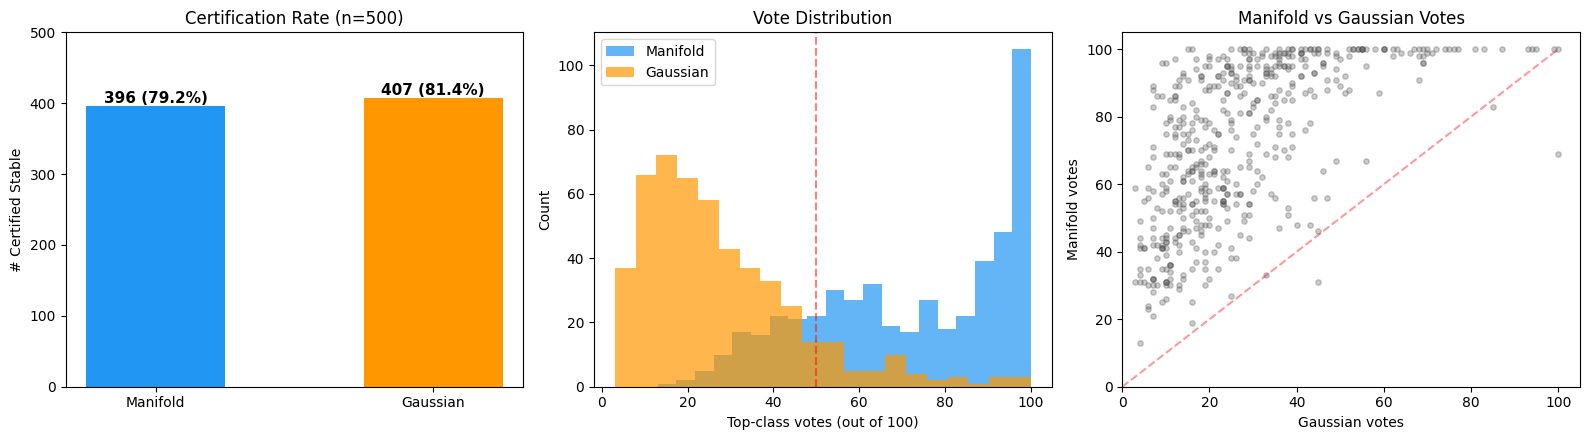

Saved: smoothing_results_summary.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# 1) Bar chart: certified stable
ax = axes[0]
bars = ax.bar(["Manifold", "Gaussian"], [m_stable, g_stable], 
              color=["#2196F3", "#FF9800"], width=0.5)
ax.set_ylabel("# Certified Stable")
ax.set_title(f"Certification Rate (n={n})")
ax.set_ylim(0, n)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 5, 
            f"{b.get_height():.0f} ({b.get_height()/n*100:.1f}%)",
            ha="center", fontsize=11, fontweight="bold")

# 2) Vote distribution histogram
ax = axes[1]
ax.hist(df["manifold_votes"], bins=20, alpha=0.7, label="Manifold", color="#2196F3")
ax.hist(df["gauss_votes"], bins=20, alpha=0.7, label="Gaussian", color="#FF9800")
ax.set_xlabel("Top-class votes (out of 100)")
ax.set_ylabel("Count")
ax.set_title("Vote Distribution")
ax.legend()
ax.axvline(50, color="red", ls="--", alpha=0.5, label="majority")

plt.tight_layout()
plt.savefig("smoothing_results_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: smoothing_results_summary.png")

In [12]:
# === Detailed Breakdown ===
print("=" * 60)
print("STABILITY CROSS-TABLE")
print("=" * 60)
ct = pd.crosstab(df["m_stable"], df["g_stable"], 
                 rownames=["Manifold Stable"], colnames=["Gaussian Stable"],
                 margins=True)
print(ct)
print()
print(f"Both stable:           {((df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Only manifold stable:  {((df['m_stable']) & (~df['g_stable'])).sum()}")
print(f"Only gaussian stable:  {((~df['m_stable']) & (df['g_stable'])).sum()}")
print(f"Neither stable:        {((~df['m_stable']) & (~df['g_stable'])).sum()}")

STABILITY CROSS-TABLE
Gaussian Stable  False  True  All
Manifold Stable                  
False               42    62  104
True                51   345  396
All                 93   407  500

Both stable:           345
Only manifold stable:  51
Only gaussian stable:  62
Neither stable:        42


In [13]:
# === Simple Results Comparison ===

results_table = pd.DataFrame({
    "": ["Original (no noise)", "Manifold Smoothed", "Gaussian Smoothed"],
    "Matches True Label": [
        f"{df['orig_correct'].sum()}/500 ({df['orig_correct'].mean()*100:.1f}%)",
        f"{df['manifold_correct'].sum()}/500 ({df['manifold_correct'].mean()*100:.1f}%)",
        f"{df['gauss_correct'].sum()}/500 ({df['gauss_correct'].mean()*100:.1f}%)",
    ],
    "Certified Stable": [
        "—",
        f"{df['m_stable'].sum()}/500 ({df['m_stable'].mean()*100:.1f}%)",
        f"{df['g_stable'].sum()}/500 ({df['g_stable'].mean()*100:.1f}%)",
    ],
    "Mean Votes": [
        "—",
        f"{df['manifold_votes'].mean():.1f}/100",
        f"{df['gauss_votes'].mean():.1f}/100",
    ],
}).set_index("")

display(results_table)

# Head-to-head: true label
both = (df["manifold_correct"] & df["gauss_correct"]).sum()
only_m = (df["manifold_correct"] & ~df["gauss_correct"]).sum()
only_g = (~df["manifold_correct"] & df["gauss_correct"]).sum()
none_ = (~df["manifold_correct"] & ~df["gauss_correct"]).sum()

h2h = pd.DataFrame({
    "": ["Both correct", "Only Manifold correct", "Only Gaussian correct", "Neither correct"],
    "Count": [both, only_m, only_g, none_],
}).set_index("")

print("\nHead-to-head (which method matches TRUE label):")
display(h2h)

,Matches True Label,Certified Stable,Mean Votes
,,,
Original (no noise),344/500 (68.8%),—,—
Manifold Smoothed,324/500 (64.8%),396/500 (79.2%),72.1/100
Gaussian Smoothed,327/500 (65.4%),407/500 (81.4%),27.4/100



Head-to-head (which method matches TRUE label):


,Count
,
Both correct,284
Only Manifold correct,40
Only Gaussian correct,43
Neither correct,133


In [15]:
# === Cases where method is UNSTABLE but corrects to true label ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    corrects = df[~df[stable_col] & df[correct_col] & ~df["orig_correct"]]
    print(f"{method} UNSTABLE but corrects to true label: {len(corrects)}")
    if len(corrects) > 0:
        display(corrects[["num","idx","true_class","orig_pred",pred_col,votes_col]].reset_index(drop=True))
    print()

# === Cases where method is STABLE but wrong (orig was already wrong) ===
for method, stable_col, correct_col, pred_col, votes_col in [
    ("Manifold", "m_stable", "manifold_correct", "manifold_pred", "manifold_votes"),
    ("Gaussian", "g_stable", "gauss_correct", "gauss_pred", "gauss_votes"),
]:
    stable_wrong = df[df[stable_col] & ~df["orig_correct"]]
    print(f"{method} STABLE but wrong (orig was wrong too): {len(stable_wrong)}")
    if len(stable_wrong) > 0:
        display(stable_wrong[["num","idx","true_class","orig_pred",pred_col,votes_col]].head(15).reset_index(drop=True))
    print()

Manifold UNSTABLE but corrects to true label: 21


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","mountain bike, all-terrain bike, off-roader",68
1,3,199,"tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri",66
2,30,33109,modem,"hard disc, hard disk, fixed disk",modem,44
3,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",54
4,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",21
5,66,20304,altar,throne,altar,65
6,74,26803,"dock, dockage, docking facility","paddlewheel, paddle wheel","dock, dockage, docking facility",43
7,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",48
8,117,9801,miniature schnauzer,Kerry blue terrier,miniature schnauzer,63
9,122,7134,dowitcher,"red-backed sandpiper, dunlin, Erolia alpina",dowitcher,49



Gaussian UNSTABLE but corrects to true label: 15


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,wire-haired fox terrier,13
1,29,37237,"projectile, missile",missile,"projectile, missile",24
2,53,3850,"wolf spider, hunting spider","harvestman, daddy longlegs, Phalangium opilio","wolf spider, hunting spider",16
3,57,30001,"hook, claw","bannister, banister, balustrade, balusters, ha...","hook, claw",7
4,104,36537,"plow, plough",oxcart,"plow, plough",11
5,109,27802,"fire screen, fireguard",strainer,"fire screen, fireguard",20
6,121,31919,maillot,"maillot, tank suit",maillot,22
7,223,48525,alp,"valley, vale",alp,29
8,280,147,"great white shark, white shark, man-eater, man...","tiger shark, Galeocerdo cuvieri","great white shark, white shark, man-eater, man...",19
9,283,43850,turnstile,"tricycle, trike, velocipede",turnstile,10



Manifold STABLE but wrong (orig was wrong too): 93


,num,idx,true_class,orig_pred,manifold_pred,manifold_votes
0,2,9427,wire-haired fox terrier,giant schnauzer,giant schnauzer,52
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,61
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,70
3,23,821,bulbul,bee eater,bee eater,76
4,29,37237,"projectile, missile",missile,missile,64
5,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",59
6,34,3918,tick,rhinoceros beetle,rhinoceros beetle,51
7,44,38340,rotisserie,safe,safe,91
8,51,24712,"chime, bell, gong",tile roof,tile roof,58
9,65,37213,"projectile, missile","aircraft carrier, carrier, flattop, attack air...","aircraft carrier, carrier, flattop, attack air...",82



Gaussian STABLE but wrong (orig was wrong too): 95


,num,idx,true_class,orig_pred,gauss_pred,gauss_votes
0,1,33553,"mountain bike, all-terrain bike, off-roader","unicycle, monocycle","unicycle, monocycle",35
1,13,6188,"spiny lobster, langouste, rock lobster, crawfi...",honeycomb,honeycomb,16
2,19,12609,"affenpinscher, monkey pinscher, monkey dog",Brabancon griffon,Brabancon griffon,16
3,23,821,bulbul,bee eater,bee eater,42
4,24,15118,"ground beetle, carabid beetle",tiger beetle,tiger beetle,23
5,30,33109,modem,"hard disc, hard disk, fixed disk","hard disc, hard disk, fixed disk",4
6,33,5503,"flatworm, platyhelminth","starfish, sea star","starfish, sea star",10
7,40,11076,Irish water spaniel,standard poodle,standard poodle,22
8,47,14644,"tiger, Panthera tigris","lynx, catamount","lynx, catamount",31
9,51,24712,"chime, bell, gong",tile roof,tile roof,7


In [16]:
# === Vote statistics for stable vs unstable ===
print("Mean manifold votes when STABLE:  ", df.loc[df['m_stable'], 'manifold_votes'].mean().round(1))
print("Mean manifold votes when UNSTABLE:", df.loc[~df['m_stable'], 'manifold_votes'].mean().round(1))
print()
print("Mean gaussian votes when STABLE:  ", df.loc[df['g_stable'], 'gauss_votes'].mean().round(1))
print("Mean gaussian votes when UNSTABLE:", df.loc[~df['g_stable'], 'gauss_votes'].mean().round(1))

Mean manifold votes when STABLE:   78.7
Mean manifold votes when UNSTABLE: 46.6

Mean gaussian votes when STABLE:   30.9
Mean gaussian votes when UNSTABLE: 12.3


In [17]:
# === Save parsed results as CSV ===
df.to_csv("smoothing_results_500.csv", index=False)
print("Saved: smoothing_results_500.csv")
print(f"\nManifold: {m_stable}/{n} ({m_stable/n*100:.1f}%) certified stable")
print(f"Gaussian: {g_stable}/{n} ({g_stable/n*100:.1f}%) certified stable")

Saved: smoothing_results_500.csv

Manifold: 396/500 (79.2%) certified stable
Gaussian: 407/500 (81.4%) certified stable


## Full Results (σ × N grid)
Load results from `run_smoothing.py` across all sigma and N combinations.

- **Section A**: σ sweep (fixed N) — effect of noise magnitude
- **Section B**: N sweep (fixed σ) — effect of number of samples on certification tightness

In [2]:
import json
import numpy as np
from pathlib import Path
import pandas as pd

# --- Config ---
SIGMAS = [0.010, 0.038, 0.066 ,0.094 ,0.121, 0.149 ,0.177, 0.204, 0.232 ]
# SIGMAS = [0.010, 0.023, 0.035, 0.048, 0.061, 0.073, 0.086, 0.099, 0.111, 0.124,
#           0.136, 0.149, 0.162, 0.174, 0.187, 0.200, 0.212, 0.225, 0.237, 0.250]
# N_VALUES = [100, 300, 500, 700, 1000]
N_VALUES=[500]
DATA_BASE = Path("..") / "smoothing_data"

# --- Load results ---
def load_results(sigma, n_samples):
    """Load JSONL results for a given sigma and N."""
    # New naming: sigma_X.XX_nN/
    data_dir = DATA_BASE / f"sigma_{sigma:.2f}_n{n_samples}"
    jsonl_path = data_dir / "smoothing_results_imagenet.jsonl"
    # Fallback to old naming: sigma_X.XX/ (for legacy N=100 runs)
    if not jsonl_path.exists():
        data_dir = DATA_BASE / f"sigma_{sigma:.2f}"
        jsonl_path = data_dir / "smoothing_results_imagenet.jsonl"
    json_path = data_dir / "smoothing_results_imagenet.json"

    results = []
    if jsonl_path.exists():
        with open(jsonl_path, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    try:
                        results.append(json.loads(line))
                    except json.JSONDecodeError:
                        pass
    elif json_path.exists():
        with open(json_path, 'r') as f:
            results = json.load(f)
    return results

# Load full grid
grid = {}  # (sigma, N) -> results
for sigma in SIGMAS:
    for n_val in N_VALUES:
        res = load_results(sigma, n_val)
        if res:
            grid[(sigma, n_val)] = res

print("Loaded grid cells:")
for (s, n), res in sorted(grid.items()):
    print(f"  σ={s:.2f}, N={n:>5d}: {len(res)} results")
print(f"\nTotal: {len(grid)} combinations")

# Helpers
def _finite(vals):
    return [v for v in vals if np.isfinite(v) and abs(v) < 1e30]

def _safe_mean(vals):
    fv = _finite(vals)
    return np.mean(fv) if fv else float('nan')

def _safe_median(vals):
    fv = _finite(vals)
    return np.median(fv) if fv else float('nan')

def _class_stats_numeric(results, method):
    cert_key = f'class_cert_{method}'
    pred_key = f'pred_{method}'
    n = len(results)
    n_certified = 0; n_correct_certified = 0; n_stable_certified = 0; n_abstained = 0
    radii = []
    for r in results:
        cc = r.get(cert_key, {})
        if cc.get('abstained', True):
            n_abstained += 1
        else:
            n_certified += 1
            rad = cc.get('certified_radius', 0)
            if np.isfinite(rad):
                radii.append(rad)
            if r[pred_key] == r['label_true']:
                n_correct_certified += 1
            if r[pred_key] == r['pred_orig']:
                n_stable_certified += 1
    return {
        'cert_acc': n_correct_certified / n if n else 0,
        'cert_stab': n_stable_certified / n if n else 0,
        'abstain': n_abstained / n if n else 0,
        'mean_r': np.mean(radii) if radii else 0,
        'median_r': np.median(radii) if radii else 0,
    }

Loaded grid cells:
  σ=0.01, N=  500: 500 results
  σ=0.04, N=  500: 500 results
  σ=0.07, N=  500: 500 results
  σ=0.09, N=  500: 500 results
  σ=0.12, N=  500: 500 results
  σ=0.15, N=  500: 500 results
  σ=0.18, N=  500: 500 results
  σ=0.20, N=  500: 500 results
  σ=0.23, N=  500: 500 results

Total: 9 combinations


### 26.05.2026 σ sweep (fixed N=100)
How does noise magnitude affect certification?

- **Two-stage class certification**: stage 1 uses `n0` samples to choose the candidate class; stage 2 uses `n` samples to certify it.
- **Certification rule**: the radius is `R = σ · Φ⁻¹(p_A_lower)` and we abstain when `p_A_lower <= 0.5`.
- **Geometry-first volume**: ttracks normalized-eigenvalue shape terms using `λ̃_i = λ_i / λ_max`, `a_i = σ · √λ̃_i`, and `V_mani,geo = C_k · σ^k · √det(Λ̃)`.
- **Certified volume**: still reported in log-space so the four legacy quantities can be compared against the new geometry-first metrics.


In [3]:
# ============================================================
# TABLES A1-A3: σ sweep at fixed N=100
# ============================================================
FIXED_N = 500
# SIGMAS = [0.010, 0.023, 0.035, 0.048, 0.061, 0.073, 0.086, 0.099, 0.111, 0.124,
#           0.136, 0.149, 0.162, 0.174, 0.187, 0.200, 0.212, 0.225, 0.237, 0.250]
sigma_results = {s: grid[(s, FIXED_N)] for s in SIGMAS if (s, FIXED_N) in grid}

if not sigma_results:
    print("No results found for N=100 across sigmas. Skipping sigma sweep.")
else:
    # --- A1: Downstream Accuracy ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        n_res = len(results)
        orig_correct = sum(1 for r in results if r['pred_orig'] == r['label_true'])
        m_correct = sum(1 for r in results if r['pred_manifold'] == r['label_true'])
        g_correct = sum(1 for r in results if r['pred_gaussian'] == r['label_true'])
        rows.append({
            'σ': s, 'Orig Acc': f"{orig_correct/n_res*100:.1f}%",
            'Manifold Acc (↑)': f"{m_correct/n_res*100:.1f}%",
            'Gaussian Acc (↑)': f"{g_correct/n_res*100:.1f}%",
        })
    print(f"TABLE A1: DOWNSTREAM ACCURACY (N={FIXED_N}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A2: Certified Downstream Accuracy ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        m = _class_stats_numeric(results, 'manifold')
        g = _class_stats_numeric(results, 'gaussian')
        rows.append({
            'σ': s,
            'Mani CertAcc (↑)': f"{m['cert_acc']*100:.1f}%",
            'Gauss CertAcc (↑)': f"{g['cert_acc']*100:.1f}%",
            'Mani Abstain (↓)': f"{m['abstain']*100:.1f}%",
            'Gauss Abstain (↓)': f"{g['abstain']*100:.1f}%",
            'Mani MeanR (↑)': f"{m['mean_r']:.4f}",
            'Gauss MeanR (↑)': f"{g['mean_r']:.4f}",
        })
    print(f"\nTABLE A2: CERTIFIED DOWNSTREAM ACCURACY (N={FIXED_N}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A3: Concept Certification ---
    TOP_K = 20
    rows = []
    for s, results in sorted(sigma_results.items()):
        rows.append({
            'σ': s,
            'Mani Survival (↑)': f"{np.mean([r.get('mean_concept_survival_manifold', 0) for r in results]):.3f}",
            'Gauss Survival (↑)': f"{np.mean([r.get('mean_concept_survival_gaussian', 0) for r in results]):.3f}",
            'Mani Overlap (↑)': f"{np.mean([r.get('overlap_manifold', 0) for r in results]):.3f}",
            'Gauss Overlap (↑)': f"{np.mean([r.get('overlap_gaussian', 0) for r in results]):.3f}",
            'Mani MeanR': f"{_safe_mean([r.get('mean_concept_radius_manifold', 0) for r in results]):.4f}",
            'Gauss MeanR': f"{_safe_mean([r.get('mean_concept_radius_gaussian', 0) for r in results]):.4f}",
        })
    print(f"\nTABLE A3: CONCEPT CERTIFICATION (N={FIXED_N}, top-{TOP_K}, varying σ)")
    display(pd.DataFrame(rows).set_index('σ'))

    # --- A4: Volume + geometry-first metrics ---
    rows = []
    for s, results in sorted(sigma_results.items()):
        r_isos = [r.get('volumes', {}).get('r_iso', 0) for r in results]
        r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]
        v1 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_D', -np.inf) for r in results])
        v2 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in results])
        v3 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_pred', -np.inf) for r in results])
        v4 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in results])
        vg_iso = _safe_mean([r.get('volumes', {}).get('log_vol_geo_iso_k', -np.inf) for r in results])
        vg_mani = _safe_mean([r.get('volumes', {}).get('log_vol_geo_mani', -np.inf) for r in results])
        vg_ratio = _safe_mean([r.get('volumes', {}).get('log_geo_ratio', -np.inf) for r in results])
        rows.append({
            'σ': s,
            'r_iso': f"{_safe_mean(r_isos):.4f}",
            'r_mani': f"{_safe_mean(r_manis):.4f}",
            'Qty1(Iso D)': f"{v1:.1f}" if np.isfinite(v1) else "N/A",
            'Qty2(Iso k)': f"{v2:.1f}" if np.isfinite(v2) else "N/A",
            'Qty3(Mani iso-r)': f"{v3:.1f}" if np.isfinite(v3) else "N/A",
            'Qty4(Mani ellip)': f"{v4:.1f}" if np.isfinite(v4) else "N/A",
            'Geo Iso': f"{vg_iso:.1f}" if np.isfinite(vg_iso) else "N/A",
            'Geo Mani': f"{vg_mani:.1f}" if np.isfinite(vg_mani) else "N/A",
            'Geo Δ': f"{vg_ratio:.1f}" if np.isfinite(vg_ratio) else "N/A",
        })
    print(f"\nTABLE A4: CERTIFIED VOLUME — legacy + geometry-first metrics (N={FIXED_N}, varying σ)")
    print("  Qty1 = C_D·r_iso^D (ambient iso ball, D=8192)")
    print("  Qty2 = C_k·r_iso^k (projected iso ball, k=PCA dim)")
    print("  Qty3 = C_k·r_iso^k·√det(Λ) (manifold geometry, iso radius)")
    print("  Qty4 = C_k·r_mani^k·√det(Λ) (full manifold ellipsoid)")
    print("  Geo Iso = C_k·σ^k, Geo Mani = C_k·σ^k·√det(Λ̃), Geo Δ = log ratio")
    display(pd.DataFrame(rows).set_index('σ'))


TABLE A1: DOWNSTREAM ACCURACY (N=500, varying σ)


,Orig Acc,Manifold Acc (↑),Gaussian Acc (↑)
σ,,,
0.010,68.8%,65.4%,68.4%
0.038,68.8%,65.2%,66.0%
0.066,68.8%,65.2%,59.4%
0.094,68.8%,65.2%,48.0%
0.121,68.8%,65.2%,35.2%
0.149,68.8%,65.0%,22.2%
0.177,68.8%,64.2%,12.6%
0.204,68.8%,64.2%,5.4%
0.232,68.8%,64.2%,2.6%



TABLE A2: CERTIFIED DOWNSTREAM ACCURACY (N=500, varying σ)


,Mani CertAcc (↑),Gauss CertAcc (↑),Mani Abstain (↓),Gauss Abstain (↓),Mani MeanR (↑),Gauss MeanR (↑)
σ,,,,,,
0.010,65.4%,68.4%,0.2%,2.2%,0.0218,0.0195
0.038,65.2%,66.0%,1.0%,14.6%,0.0802,0.0573
0.066,65.2%,59.4%,1.8%,29.0%,0.1356,0.0763
0.094,65.2%,48.0%,1.8%,45.4%,0.1878,0.0838
0.121,65.2%,35.2%,2.4%,61.0%,0.2365,0.0843
0.149,65.0%,22.2%,3.6%,75.2%,0.2861,0.0830
0.177,64.2%,12.6%,4.8%,86.6%,0.3342,0.0855
0.204,64.2%,5.4%,6.2%,94.4%,0.3786,0.1085
0.232,64.2%,2.6%,6.8%,97.4%,0.4199,0.1323



TABLE A3: CONCEPT CERTIFICATION (N=500, top-20, varying σ)


,Mani Survival (↑),Gauss Survival (↑),Mani Overlap (↑),Gauss Overlap (↑),Mani MeanR,Gauss MeanR
σ,,,,,,
0.010,0.799,0.989,0.799,0.989,0.0219,0.0214
0.038,0.799,0.963,0.799,0.963,0.0825,0.0760
0.066,0.799,0.940,0.799,0.940,0.1416,0.1241
0.094,0.798,0.916,0.798,0.916,0.1993,0.1672
0.121,0.797,0.894,0.797,0.894,0.2536,0.2041
0.149,0.796,0.870,0.796,0.870,0.3085,0.2390
0.177,0.795,0.845,0.795,0.845,0.3617,0.2708
0.204,0.793,0.822,0.793,0.822,0.4119,0.2989
0.232,0.792,0.795,0.792,0.795,0.4620,0.3264



TABLE A4: CERTIFIED VOLUME — legacy + geometry-first metrics (N=500, varying σ)
  Qty1 = C_D·r_iso^D (ambient iso ball, D=8192)
  Qty2 = C_k·r_iso^k (projected iso ball, k=PCA dim)
  Qty3 = C_k·r_iso^k·√det(Λ) (manifold geometry, iso radius)
  Qty4 = C_k·r_mani^k·√det(Λ) (full manifold ellipsoid)
  Geo Iso = C_k·σ^k, Geo Mani = C_k·σ^k·√det(Λ̃), Geo Δ = log ratio


,r_iso,r_mani,Qty1(Iso D),Qty2(Iso k),Qty3(Mani iso-r),Qty4(Mani ellip),Geo Iso,Geo Mani,Geo Δ
σ,,,,,,,,,
0.010,0.0190,0.0218,-58672.9,-2863.0,-3837.9,-3719.5,-3125.9,-4363.7,-1237.8
0.038,0.0489,0.0794,-50755.8,-2383.1,-3356.4,-3085.7,-2463.2,-3701.0,-1237.8
0.066,0.0542,0.1331,-49070.2,-2281.0,-3253.6,-2833.2,-2189.2,-3427.0,-1237.8
0.094,0.0458,0.1844,-48745.9,-2263.0,-3232.3,-2692.7,-2013.7,-3251.4,-1237.8
0.121,0.0329,0.2308,-49370.3,-2301.8,-3259.8,-2595.4,-1888.3,-3126.1,-1237.8
0.149,0.0206,0.2758,-49841.1,-2331.7,-3276.8,-2507.8,-1785.0,-3022.8,-1237.8
0.177,0.0115,0.3181,-50200.5,-2357.0,-3299.0,-2433.2,-1699.5,-2937.3,-1237.8
0.204,0.0061,0.3551,-48076.5,-2228.5,-3160.7,-2368.0,-1629.0,-2866.8,-1237.8
0.232,0.0034,0.3914,-44859.4,-2034.7,-3016.5,-2328.7,-1565.2,-2803.0,-1237.8


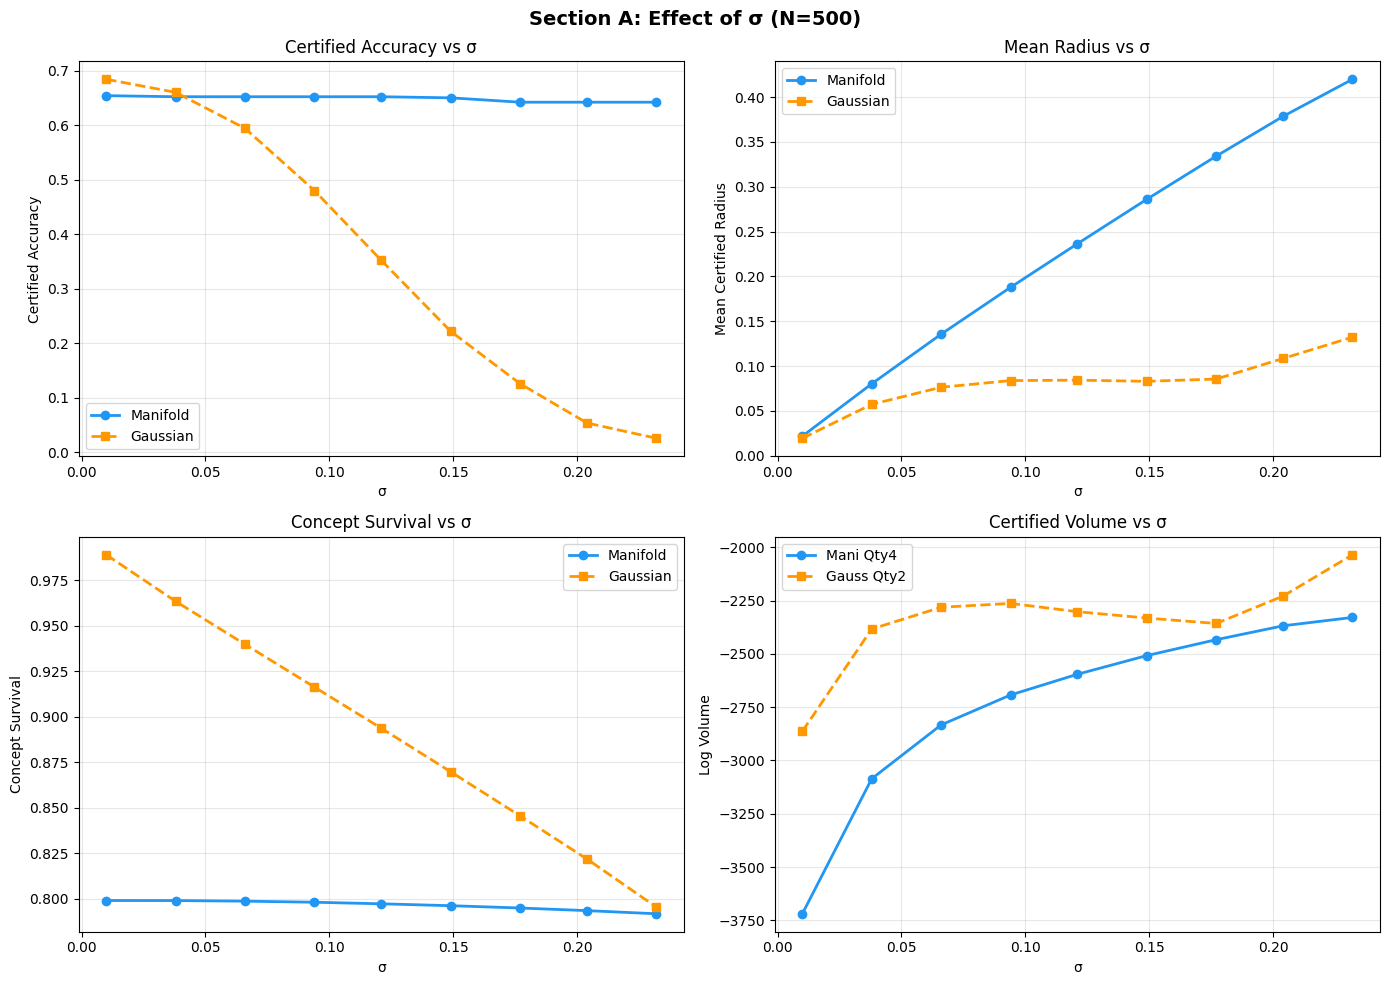

In [4]:
# ============================================================
# PLOTS A: σ sweep at fixed N=100
# ============================================================
import matplotlib.pyplot as plt

if sigma_results:
    s_vals = sorted(sigma_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cert Acc vs σ
    ax = axes[0, 0]
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'manifold')['cert_acc'] for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'gaussian')['cert_acc'] for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Certified Accuracy'); ax.set_title('Certified Accuracy vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Mean Radius vs σ
    ax = axes[0, 1]
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'manifold')['mean_r'] for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [_class_stats_numeric(sigma_results[s], 'gaussian')['mean_r'] for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Mean Certified Radius'); ax.set_title('Mean Radius vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Concept Survival vs σ
    ax = axes[1, 0]
    ax.plot(s_vals, [np.mean([r.get('mean_concept_survival_manifold', 0) for r in sigma_results[s]]) for s in s_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(s_vals, [np.mean([r.get('mean_concept_survival_gaussian', 0) for r in sigma_results[s]]) for s in s_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Concept Survival'); ax.set_title('Concept Survival vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Volume vs σ
    ax = axes[1, 1]
    ax.plot(s_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in sigma_results[s]]) for s in s_vals],
            'o-', color='#2196F3', label='Mani Qty4', linewidth=2)
    ax.plot(s_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in sigma_results[s]]) for s in s_vals],
            's--', color='#FF9800', label='Gauss Qty2', linewidth=2)
    ax.set_xlabel('σ'); ax.set_ylabel('Log Volume'); ax.set_title('Certified Volume vs σ')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Section A: Effect of σ (N={FIXED_N})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("sigma_sweep_plots.png", dpi=150, bbox_inches="tight")
    plt.show()

### Section B: N sweep (per σ)
How does the number of smoothing samples affect certification tightness? Loops over all σ values found in the grid.

In [5]:
# ============================================================
# TABLES B: N sweep — for EVERY σ found in the grid
# ============================================================

# Find which sigmas actually have multiple N values
sigmas_with_n_sweep = {}
for sigma in SIGMAS:
    n_res = {n: grid[(sigma, n)] for n in N_VALUES if (sigma, n) in grid}
    if len(n_res) > 1:  # need at least 2 N values to be a sweep
        sigmas_with_n_sweep[sigma] = n_res

if not sigmas_with_n_sweep:
    print("No sigma has results for multiple N values. Skipping N sweep.")
else:
    for sigma, n_results in sorted(sigmas_with_n_sweep.items()):
        print(f"\n{'#'*80}")
        print(f"  σ = {sigma:.2f}  ({len(n_results)} N values: {sorted(n_results.keys())})")
        print(f"{'#'*80}")

        # --- B1: Downstream Accuracy ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            n_res = len(results)
            orig_correct = sum(1 for r in results if r['pred_orig'] == r['label_true'])
            m_correct = sum(1 for r in results if r['pred_manifold'] == r['label_true'])
            g_correct = sum(1 for r in results if r['pred_gaussian'] == r['label_true'])
            rows.append({
                'N': n_val, 'Orig Acc': f"{orig_correct/n_res*100:.1f}%",
                'Manifold Acc (↑)': f"{m_correct/n_res*100:.1f}%",
                'Gaussian Acc (↑)': f"{g_correct/n_res*100:.1f}%",
            })
        print(f"\nTABLE B1: DOWNSTREAM ACCURACY (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B2: Certified Downstream Accuracy ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            m = _class_stats_numeric(results, 'manifold')
            g = _class_stats_numeric(results, 'gaussian')
            rows.append({
                'N': n_val,
                'Mani CertAcc (↑)': f"{m['cert_acc']*100:.1f}%",
                'Gauss CertAcc (↑)': f"{g['cert_acc']*100:.1f}%",
                'Mani Abstain (↓)': f"{m['abstain']*100:.1f}%",
                'Gauss Abstain (↓)': f"{g['abstain']*100:.1f}%",
                'Mani MeanR (↑)': f"{m['mean_r']:.4f}",
                'Gauss MeanR (↑)': f"{g['mean_r']:.4f}",
            })
        print(f"\nTABLE B2: CERTIFIED DOWNSTREAM ACCURACY (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B3: Concept Certification ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            rows.append({
                'N': n_val,
                'Mani Survival (↑)': f"{np.mean([r.get('mean_concept_survival_manifold', 0) for r in results]):.3f}",
                'Gauss Survival (↑)': f"{np.mean([r.get('mean_concept_survival_gaussian', 0) for r in results]):.3f}",
                'Mani MeanR (↑)': f"{_safe_mean([r.get('mean_concept_radius_manifold', 0) for r in results]):.4f}",
                'Gauss MeanR (↑)': f"{_safe_mean([r.get('mean_concept_radius_gaussian', 0) for r in results]):.4f}",
            })
        print(f"\nTABLE B3: CONCEPT CERTIFICATION (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))

        # --- B4: Volume + geometry-first metrics ---
        rows = []
        for n_val, results in sorted(n_results.items()):
            r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]
            v4 = _safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in results])
            v2 = _safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in results])
            vg_iso = _safe_mean([r.get('volumes', {}).get('log_vol_geo_iso_k', -np.inf) for r in results])
            vg_mani = _safe_mean([r.get('volumes', {}).get('log_vol_geo_mani', -np.inf) for r in results])
            vg_ratio = _safe_mean([r.get('volumes', {}).get('log_geo_ratio', -np.inf) for r in results])
            rows.append({
                'N': n_val,
                'r_mani mean': f"{_safe_mean(r_manis):.4f}",
                'Qty4(Mani) mean': f"{v4:.1f}" if np.isfinite(v4) else "N/A",
                'Qty2(Iso k) mean': f"{v2:.1f}" if np.isfinite(v2) else "N/A",
                'Geo Iso mean': f"{vg_iso:.1f}" if np.isfinite(vg_iso) else "N/A",
                'Geo Mani mean': f"{vg_mani:.1f}" if np.isfinite(vg_mani) else "N/A",
                'Geo Δ mean': f"{vg_ratio:.1f}" if np.isfinite(vg_ratio) else "N/A",
            })
        print(f"\nTABLE B4: CERTIFIED VOLUME + geometry-first metrics (σ={sigma:.2f}, varying N)")
        display(pd.DataFrame(rows).set_index('N'))


No sigma has results for multiple N values. Skipping N sweep.


In [6]:
# ============================================================
# PLOTS B: N sweep — one 2×2 figure per σ
# ============================================================
for sigma, n_results in sorted(sigmas_with_n_sweep.items()):
    n_vals = sorted(n_results.keys())
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    # Cert Acc vs N
    ax = axes[0, 0]
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'manifold')['cert_acc'] for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'gaussian')['cert_acc'] for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Certified Accuracy'); ax.set_title('Certified Accuracy vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Mean Radius vs N
    ax = axes[0, 1]
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'manifold')['mean_r'] for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [_class_stats_numeric(n_results[n], 'gaussian')['mean_r'] for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Mean Certified Radius'); ax.set_title('Mean Radius vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Concept Survival vs N
    ax = axes[1, 0]
    ax.plot(n_vals, [np.mean([r.get('mean_concept_survival_manifold', 0) for r in n_results[n]]) for n in n_vals],
            'o-', color='#2196F3', label='Manifold', linewidth=2)
    ax.plot(n_vals, [np.mean([r.get('mean_concept_survival_gaussian', 0) for r in n_results[n]]) for n in n_vals],
            's--', color='#FF9800', label='Gaussian', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Concept Survival'); ax.set_title('Concept Survival vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    # Volume vs N
    ax = axes[1, 1]
    ax.plot(n_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_mani_actual', -np.inf) for r in n_results[n]]) for n in n_vals],
            'o-', color='#2196F3', label='Mani Qty4', linewidth=2)
    ax.plot(n_vals, [_safe_mean([r.get('volumes', {}).get('log_vol_iso_k', -np.inf) for r in n_results[n]]) for n in n_vals],
            's--', color='#FF9800', label='Gauss Qty2', linewidth=2)
    ax.set_xlabel('N (samples)'); ax.set_ylabel('Log Volume'); ax.set_title('Certified Volume vs N')
    ax.legend(); ax.grid(True, alpha=0.3)

    plt.suptitle(f'Section B: Effect of N (σ={sigma:.2f})', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"n_sweep_sigma_{sigma:.2f}.png", dpi=150, bbox_inches="tight")
    plt.show()

,sigma,mani_cert_acc,gauss_cert_acc,mani_mean_r,gauss_mean_r,mani_abstain,gauss_abstain
0,0.010,0.654,0.684,0.021797,0.019451,0.002,0.022
1,0.038,0.652,0.660,0.080205,0.057311,0.010,0.146
2,0.066,0.652,0.594,0.135565,0.076338,0.018,0.290
3,0.094,0.652,0.480,0.187802,0.083814,0.018,0.454
4,0.121,0.652,0.352,0.236458,0.084273,0.024,0.610
5,0.149,0.650,0.222,0.286052,0.082993,0.036,0.752
6,0.177,0.642,0.126,0.334177,0.085526,0.048,0.866
7,0.204,0.642,0.054,0.378580,0.108476,0.062,0.944
8,0.232,0.642,0.026,0.419917,0.132280,0.068,0.974
9,0.250,0.648,0.350,0.434036,0.012977,0.044,0.612



Same-guarantee matching (target = manifold certified accuracy)


,target_mani_cert_acc,sigma_mani,sigma_gauss_closest,gauss_cert_acc_at_closest,abs_acc_gap,sigma_gap
0,0.654,0.010,0.038,0.66,0.006,0.028
1,0.652,0.038,0.038,0.66,0.008,0.000
2,0.652,0.066,0.038,0.66,0.008,-0.028
3,0.652,0.094,0.038,0.66,0.008,-0.056
4,0.652,0.121,0.038,0.66,0.008,-0.083
5,0.650,0.149,0.038,0.66,0.010,-0.111
9,0.648,0.250,0.038,0.66,0.012,-0.212
6,0.642,0.177,0.038,0.66,0.018,-0.139
7,0.642,0.204,0.038,0.66,0.018,-0.166
8,0.642,0.232,0.038,0.66,0.018,-0.194


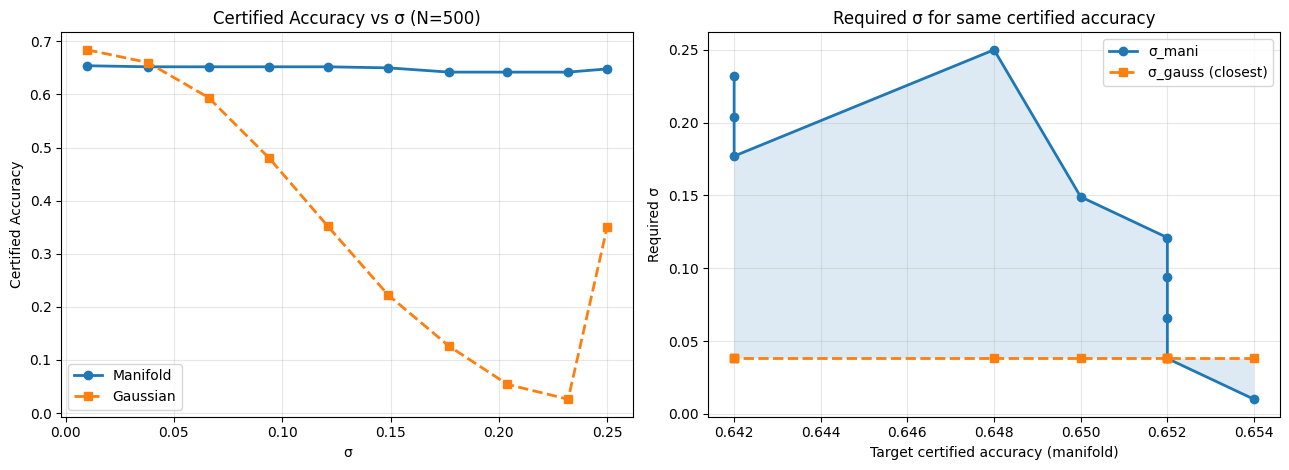

In [12]:
# ============================================================
# EXTRA ANALYSIS 1: Same certified-accuracy matching (Manifold vs Gaussian)
# ============================================================

import pandas as pd

if not grid:
    print("Grid is empty. Run the loading cell first.")
else:
    match_rows = []

    # Use N=100 by default for sigma-vs-sigma matching
    MATCH_N = 500
    avail_sigmas = sorted([s for (s, n) in grid.keys() if n == MATCH_N])

    if not avail_sigmas:
        print(f"No runs available for N={MATCH_N}.")
    else:
        for s in avail_sigmas:
            results = grid[(s, MATCH_N)]
            m = _class_stats_numeric(results, 'manifold')
            g = _class_stats_numeric(results, 'gaussian')
            match_rows.append({
                'sigma': s,
                'mani_cert_acc': m['cert_acc'],
                'gauss_cert_acc': g['cert_acc'],
                'mani_mean_r': m['mean_r'],
                'gauss_mean_r': g['mean_r'],
                'mani_abstain': m['abstain'],
                'gauss_abstain': g['abstain'],
            })

        df_match_src = pd.DataFrame(match_rows).sort_values('sigma').reset_index(drop=True)
        display(df_match_src)

        # For each manifold target accuracy, find closest gaussian sigma
        same_acc_rows = []
        for _, row in df_match_src.iterrows():
            target = row['mani_cert_acc']
            idx = (df_match_src['gauss_cert_acc'] - target).abs().idxmin()
            g_row = df_match_src.loc[idx]
            same_acc_rows.append({
                'target_mani_cert_acc': target,
                'sigma_mani': row['sigma'],
                'sigma_gauss_closest': g_row['sigma'],
                'gauss_cert_acc_at_closest': g_row['gauss_cert_acc'],
                'abs_acc_gap': abs(g_row['gauss_cert_acc'] - target),
                'sigma_gap': g_row['sigma'] - row['sigma'],
            })

        df_same_acc = pd.DataFrame(same_acc_rows).sort_values('target_mani_cert_acc', ascending=False)
        print("\nSame-guarantee matching (target = manifold certified accuracy)")
        display(df_same_acc)

        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

        # Left: certified-accuracy curves
        axes[0].plot(df_match_src['sigma'], df_match_src['mani_cert_acc'], 'o-', label='Manifold', linewidth=2)
        axes[0].plot(df_match_src['sigma'], df_match_src['gauss_cert_acc'], 's--', label='Gaussian', linewidth=2)
        axes[0].set_title(f'Certified Accuracy vs σ (N={MATCH_N})')
        axes[0].set_xlabel('σ')
        axes[0].set_ylabel('Certified Accuracy')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        # Right: required sigma at matched guarantee
        axes[1].plot(df_same_acc['target_mani_cert_acc'], df_same_acc['sigma_mani'], 'o-', label='σ_mani', linewidth=2)
        axes[1].plot(df_same_acc['target_mani_cert_acc'], df_same_acc['sigma_gauss_closest'], 's--', label='σ_gauss (closest)', linewidth=2)
        axes[1].fill_between(
            df_same_acc['target_mani_cert_acc'],
            df_same_acc['sigma_mani'],
            df_same_acc['sigma_gauss_closest'],
            alpha=0.15,
        )
        axes[1].set_title('Required σ for same certified accuracy')
        axes[1].set_xlabel('Target certified accuracy (manifold)')
        axes[1].set_ylabel('Required σ')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

## Section C: Target Certified-Accuracy — Which σ is needed?\nFor each target certified accuracy level, show what σ manifold vs isotropic needs.\nCovers both **20 fine-grained sigmas** (0.01→0.25) and **5 coarse sigmas** (0.25, 0.50, 0.70, 0.75, 1.00).

In [7]:
# ============================================================
# SECTION C: Target Accuracy — Required σ (Manifold vs Gaussian)
# Two sigma sets:
#   SET1 (fine): 20 values 0.01 → 0.25  (from existing grid)
#   SET2 (coarse): [0.25, 0.50, 0.70, 0.75, 1.00]  (big sigmas)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

FINE_SIGMAS  = [0.010, 0.023, 0.035, 0.048, 0.061, 0.073, 0.086, 0.099,
                0.111, 0.124, 0.136, 0.149, 0.162, 0.174, 0.187, 0.200,
                0.212, 0.225, 0.237, 0.250]
COARSE_SIGMAS = [0.25, 0.50, 0.70, 0.75, 1.00]
MATCH_N = 100   # use N=100 runs for the sigma-matching analysis

def _build_acc_df(sigma_list, n_val, grid):
    rows = []
    for s in sigma_list:
        key = (round(s, 3), n_val)
        # try exact match first, then nearest stored key
        res = grid.get(key) or grid.get((s, n_val))
        if res is None:
            # find closest sigma in grid for this N
            candidates = [(k, v) for k, v in grid.items() if k[1] == n_val]
            if candidates:
                best = min(candidates, key=lambda kv: abs(kv[0][0] - s))
                res = best[1]
                s_used = best[0][0]
            else:
                continue
        else:
            s_used = s
        m = _class_stats_numeric(res, 'manifold')
        g = _class_stats_numeric(res, 'gaussian')
        rows.append({
            'sigma_requested': s,
            'sigma_used': s_used,
            'mani_cert_acc': m['cert_acc'],
            'gauss_cert_acc': g['cert_acc'],
            'mani_mean_r': m['mean_r'],
            'gauss_mean_r': g['mean_r'],
            'mani_abstain': m['abstain'],
            'gauss_abstain': g['abstain'],
        })
    return pd.DataFrame(rows).sort_values('sigma_requested').reset_index(drop=True)

df_fine   = _build_acc_df(FINE_SIGMAS,   MATCH_N, grid)
df_coarse = _build_acc_df(COARSE_SIGMAS, MATCH_N, grid)

def _same_accuracy_matching(df):
    """For each manifold (σ, acc), find the closest Gaussian σ that achieves the same acc."""
    rows = []
    for _, row in df.iterrows():
        target = row['mani_cert_acc']
        idx = (df['gauss_cert_acc'] - target).abs().idxmin()
        g_row = df.loc[idx]
        rows.append({
            'sigma_mani':         round(row['sigma_used'], 4),
            'mani_cert_acc':      round(row['mani_cert_acc'], 4),
            'sigma_gauss_match':  round(g_row['sigma_used'], 4),
            'gauss_cert_acc_at_match': round(g_row['gauss_cert_acc'], 4),
            'acc_gap':            round(abs(g_row['gauss_cert_acc'] - target), 4),
            'sigma_gap':          round(g_row['sigma_used'] - row['sigma_used'], 4),
        })
    return pd.DataFrame(rows)

df_match_fine   = _same_accuracy_matching(df_fine)
df_match_coarse = _same_accuracy_matching(df_coarse)

print("── Fine sigmas (0.01 → 0.25), N=100 ─────────────────────────────────")
display(df_match_fine)
print("\n── Coarse sigmas (0.25, 0.50, 0.70, 0.75, 1.00), N=100 ──────────────")
display(df_match_coarse)


KeyError: 'sigma_requested'

NameError: name 'df_fine' is not defined

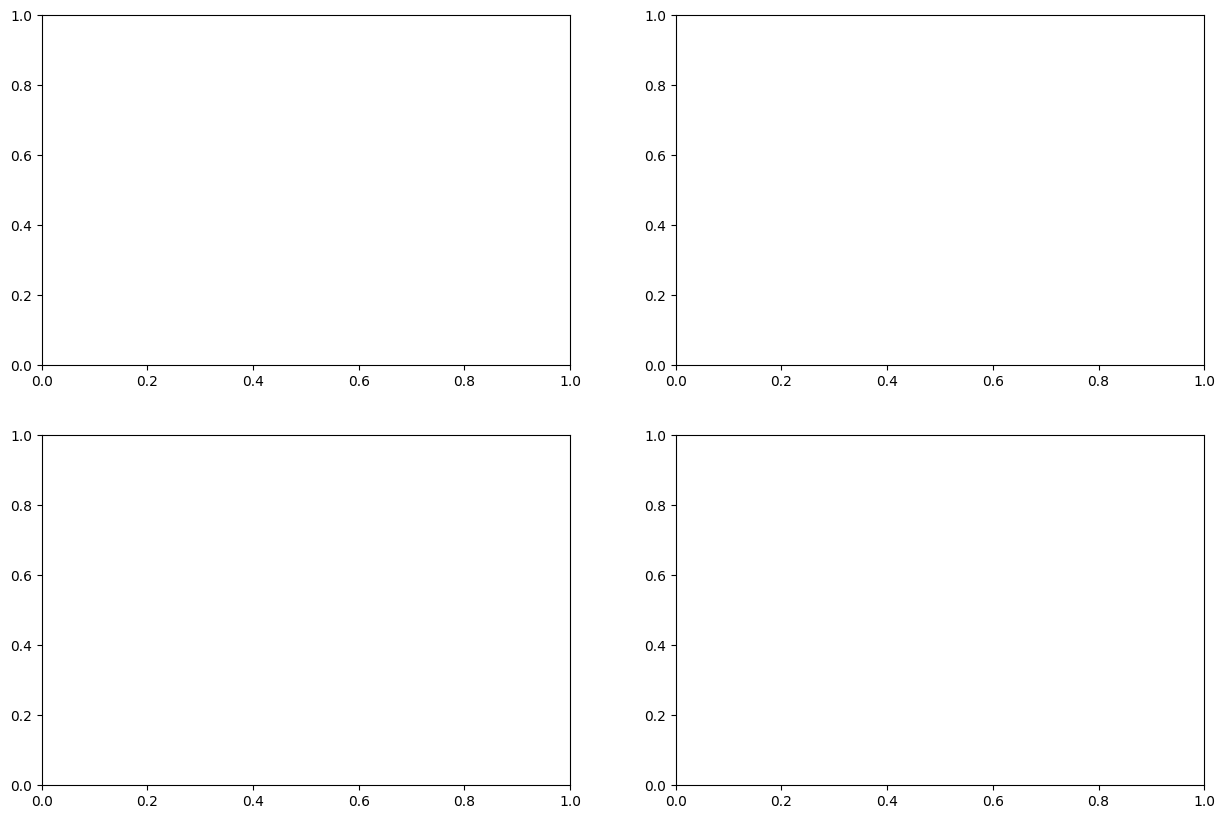

In [8]:
# ─── Plots C: accuracy curves + required σ side-by-side ─────────────────────
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for row_i, (df_src, df_match, label) in enumerate([
    (df_fine,   df_match_fine,   'Fine (0.01→0.25)'),
    (df_coarse, df_match_coarse, 'Coarse (0.25–1.00)'),
]):
    if df_src.empty:
        continue

    # Left: accuracy curves
    ax = axes[row_i, 0]
    ax.plot(df_src['sigma_used'], df_src['mani_cert_acc'],  'o-', lw=2,
            color='#2196F3', label='Manifold')
    ax.plot(df_src['sigma_used'], df_src['gauss_cert_acc'], 's--', lw=2,
            color='#FF9800', label='Gaussian')
    ax.set_title(f'{label}: Certified Accuracy vs σ (N={MATCH_N})')
    ax.set_xlabel('σ'); ax.set_ylabel('Certified Accuracy')
    ax.grid(True, alpha=0.3); ax.legend()

    # Right: required σ for same target accuracy
    ax = axes[row_i, 1]
    if not df_match.empty:
        ax.plot(df_match['mani_cert_acc'], df_match['sigma_mani'],
                'o-', lw=2, color='#2196F3', label='σ_mani')
        ax.plot(df_match['mani_cert_acc'], df_match['sigma_gauss_match'],
                's--', lw=2, color='#FF9800', label='σ_gauss (matched)')
        ax.fill_between(df_match['mani_cert_acc'],
                        df_match['sigma_mani'],
                        df_match['sigma_gauss_match'],
                        alpha=0.12, color='gray', label='σ gap')
        for _, r in df_match.iterrows():
            if abs(r['sigma_gap']) > 0.001:
                ax.annotate(f"Δ{r['sigma_gap']:+.3f}",
                            (r['mani_cert_acc'], max(r['sigma_mani'], r['sigma_gauss_match'])),
                            fontsize=6.5, ha='center', va='bottom', color='#555')
    ax.set_title(f'{label}: Required σ at Same Guarantee')
    ax.set_xlabel('Target Certified Accuracy'); ax.set_ylabel('Required σ')
    ax.grid(True, alpha=0.3); ax.legend(fontsize=8)

plt.suptitle('Section C: Manifold vs Gaussian — Same Accuracy Matching', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section_c_sigma_matching.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section_c_sigma_matching.png")
print("\nInterpretation: if σ_gap > 0, manifold reaches the same guarantee with LESS noise.")


## Section D: Volume Analysis + Eigen/Axis Spectrum\nGeometry-first certified volume metrics and per-σ eigenvalue/axis diagnostics.\n\n- **Geo Ratio** = log(V_mani / V_iso) — positive means manifold has larger certified region\n- **Anisotropy** = a₁/aₖ — how stretched the ellipsoid is relative to its smallest axis\n- **Effective Rank** — entropy-based dimensionality of the local manifold\n- **Axis spectrum** — a_i = σ · √λ̃_i shows how far each PCA axis contributes to the ellipse

In [9]:
# ============================================================
# SECTION D1: Volume metrics table across ALL sigma×N cells
# ============================================================
from scipy.special import gammaln

def _axis_lengths(sigma, evals_norm):
    evals_norm = np.asarray(evals_norm, dtype=np.float64)
    return sigma * np.sqrt(np.maximum(evals_norm, 0.0))

vol_rows = []
for (s, n_val), results in sorted(grid.items()):
    r_isos  = [r.get('volumes', {}).get('r_iso', 0)  for r in results]
    r_manis = [r.get('volumes', {}).get('r_mani', 0) for r in results]

    def vm(key):
        return _safe_mean([r.get('volumes', {}).get(key, -np.inf) for r in results])

    aniso_vals = [r.get('volumes', {}).get('anisotropy_ratio', 0.0) for r in results
                  if r.get('volumes', {}).get('anisotropy_ratio', 0.0) > 0]
    eff_rank_vals = [r.get('volumes', {}).get('eigen_effective_rank', 0.0) for r in results
                     if r.get('volumes', {}).get('eigen_effective_rank', 0.0) > 0]

    vol_rows.append({
        'σ': s, 'N': n_val,
        'r_iso':    round(_safe_mean(r_isos), 4),
        'r_mani':   round(_safe_mean(r_manis), 4),
        'v_mani':round(vm('log_vol_geo_mani'), 2)    if np.isfinite(vm('log_vol_geo_mani')) else float('nan'),
        'v_iso':round(vm('log_vol_geo_iso_k'), 2)    if np.isfinite(vm('log_vol_geo_iso_k')) else float('nan'),
        'Qty1(Iso D)':     round(vm('log_vol_iso_D'), 2)    if np.isfinite(vm('log_vol_iso_D')) else float('nan'),
        'Qty2(Iso k)':     round(vm('log_vol_iso_k'), 2)    if np.isfinite(vm('log_vol_iso_k')) else float('nan'),
        'Qty3(Mani iso-r)':round(vm('log_vol_mani_pred'), 2)if np.isfinite(vm('log_vol_mani_pred')) else float('nan'),
        'Qty4(Mani ellip)':round(vm('log_vol_mani_actual'), 2) if np.isfinite(vm('log_vol_mani_actual')) else float('nan'),
        'Geo Δ':     round(vm('log_geo_ratio'), 3)          if np.isfinite(vm('log_geo_ratio')) else float('nan'),
        'Anisotropy':round(float(np.mean(aniso_vals)), 3)   if aniso_vals else float('nan'),
        'Eff.Rank':  round(float(np.mean(eff_rank_vals)), 2) if eff_rank_vals else float('nan'),
    })

df_vol = pd.DataFrame(vol_rows).sort_values(['σ', 'N'])
print("Volume metrics across σ × N grid:")
display(df_vol.round(4))


Volume metrics across σ × N grid:


,σ,N,r_iso,r_mani,v_mani,v_iso,Qty1(Iso D),Qty2(Iso k),Qty3(Mani iso-r),Qty4(Mani ellip),Geo Δ,Anisotropy,Eff.Rank
0,0.010,500,0.0190,0.0218,-4363.71,-3125.92,-58672.88,-2863.03,-3837.91,-3719.49,-1237.787,142.777,135.51
1,0.038,500,0.0489,0.0794,-3701.03,-2463.24,-50755.78,-2383.06,-3356.37,-3085.66,-1237.787,142.777,135.51
2,0.066,500,0.0542,0.1331,-3426.99,-2189.20,-49070.16,-2281.05,-3253.59,-2833.20,-1237.787,142.777,135.51
3,0.094,500,0.0458,0.1844,-3251.45,-2013.66,-48745.95,-2262.95,-3232.30,-2692.72,-1237.787,142.777,135.51
4,0.121,500,0.0329,0.2308,-3126.11,-1888.33,-49370.35,-2301.79,-3259.79,-2595.41,-1237.787,142.777,135.51
5,0.149,500,0.0206,0.2758,-3022.79,-1785.00,-49841.11,-2331.70,-3276.78,-2507.76,-1237.787,142.777,135.51
6,0.177,500,0.0115,0.3181,-2937.31,-1699.52,-50200.46,-2356.98,-3299.01,-2433.24,-1237.787,142.777,135.51
7,0.204,500,0.0061,0.3551,-2866.84,-1629.05,-48076.50,-2228.47,-3160.66,-2368.01,-1237.787,142.777,135.51
8,0.232,500,0.0034,0.3914,-2802.99,-1565.20,-44859.41,-2034.71,-3016.48,-2328.67,-1237.787,142.777,135.51


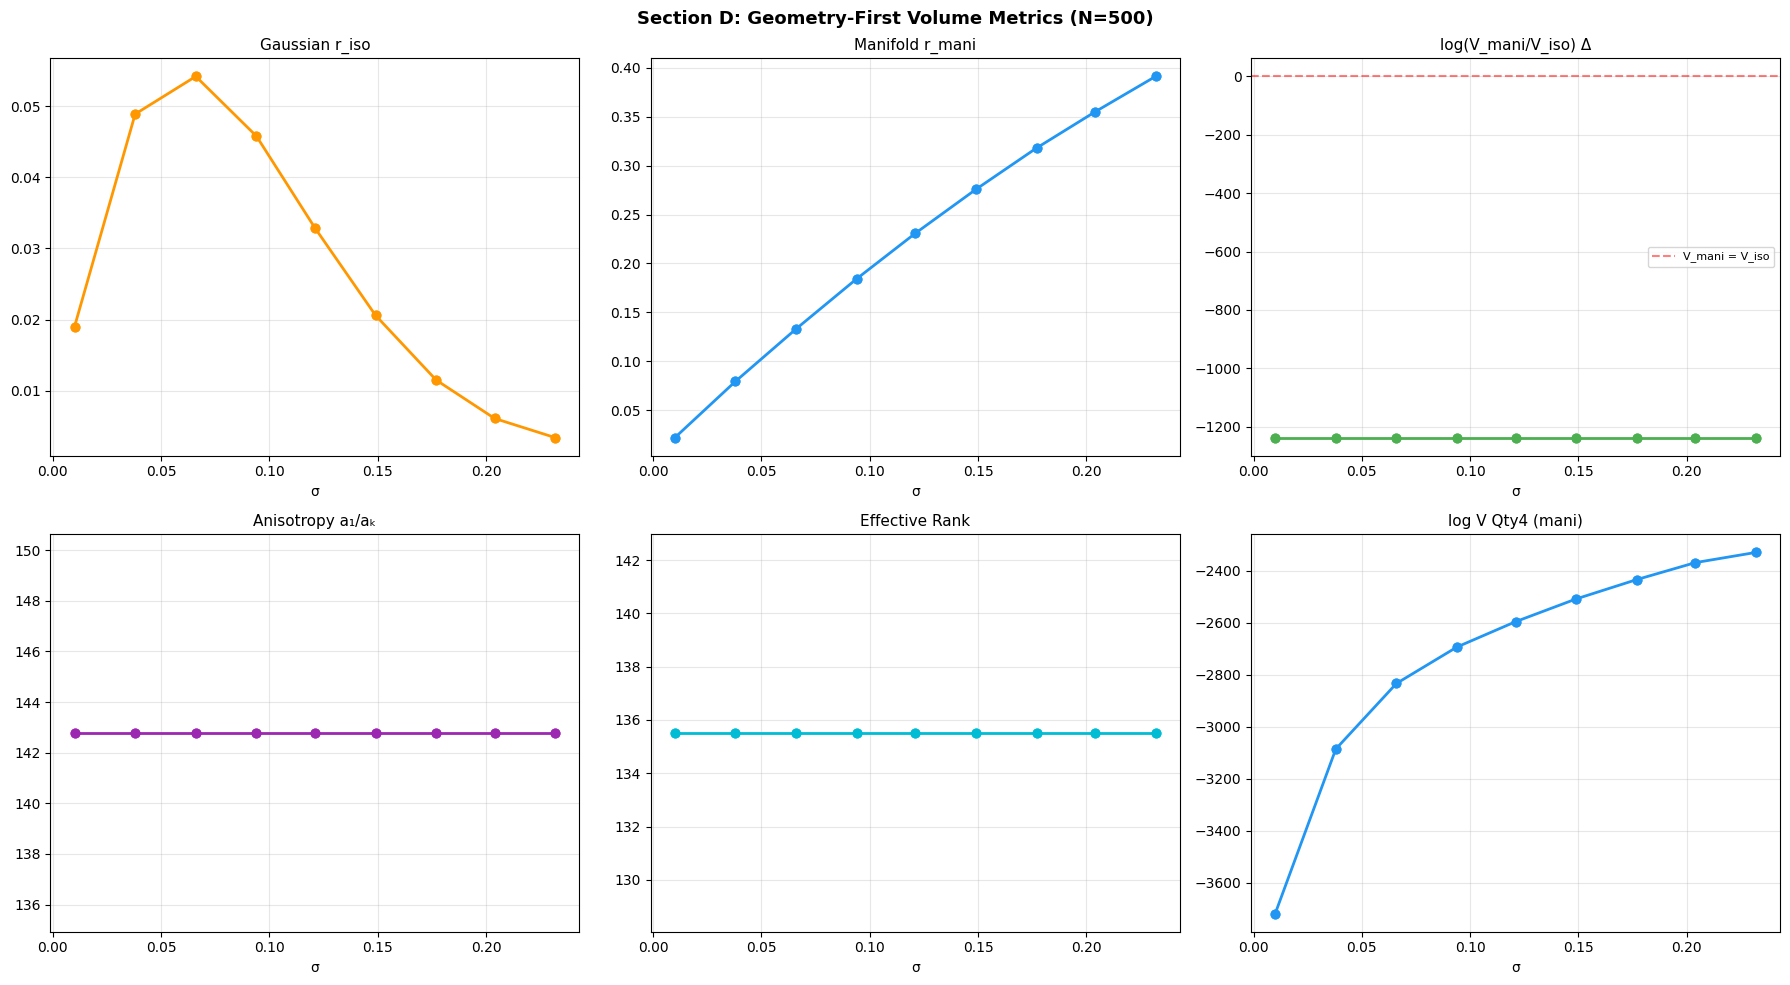

Saved: section_d_volume_geometry.png


In [10]:
# ─── D2: Geometry plots (fixed N=100, sweep σ) ──────────────────────────────
FIXED_N_D = 500
df_vol_n100 = df_vol[df_vol['N'] == FIXED_N_D].sort_values('σ')

if df_vol_n100.empty:
    print(f"No data for N={FIXED_N_D}; using all N values combined (first N per σ).")
    df_vol_n100 = df_vol.groupby('σ').first().reset_index().sort_values('σ')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metrics = [
    ('r_iso',         'Gaussian r_iso',        '#FF9800'),
    ('r_mani',        'Manifold r_mani',        '#2196F3'),
    ('Geo Δ',         'log(V_mani/V_iso) Δ',   '#4CAF50'),
    ('Anisotropy',    'Anisotropy a₁/aₖ',      '#9C27B0'),
    ('Eff.Rank',      'Effective Rank',         '#00BCD4'),
    ('Qty4(Mani ellip)', 'log V Qty4 (mani)',  '#2196F3'),
]

for ax, (col, title, color) in zip(axes.flat, metrics):
    vals = pd.to_numeric(df_vol_n100[col], errors='coerce')
    mask = vals.notna()
    if mask.sum() > 0:
        ax.plot(df_vol_n100['σ'][mask], vals[mask], 'o-', lw=2, color=color)
        ax.scatter(df_vol_n100['σ'][mask], vals[mask], s=40, color=color, zorder=5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('σ')
    ax.grid(True, alpha=0.3)
    if col == 'Geo Δ':
        ax.axhline(0, color='red', ls='--', alpha=0.5, label='V_mani = V_iso')
        ax.legend(fontsize=8)

plt.suptitle(f'Section D: Geometry-First Volume Metrics (N={FIXED_N_D})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('section_d_volume_geometry.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: section_d_volume_geometry.png")


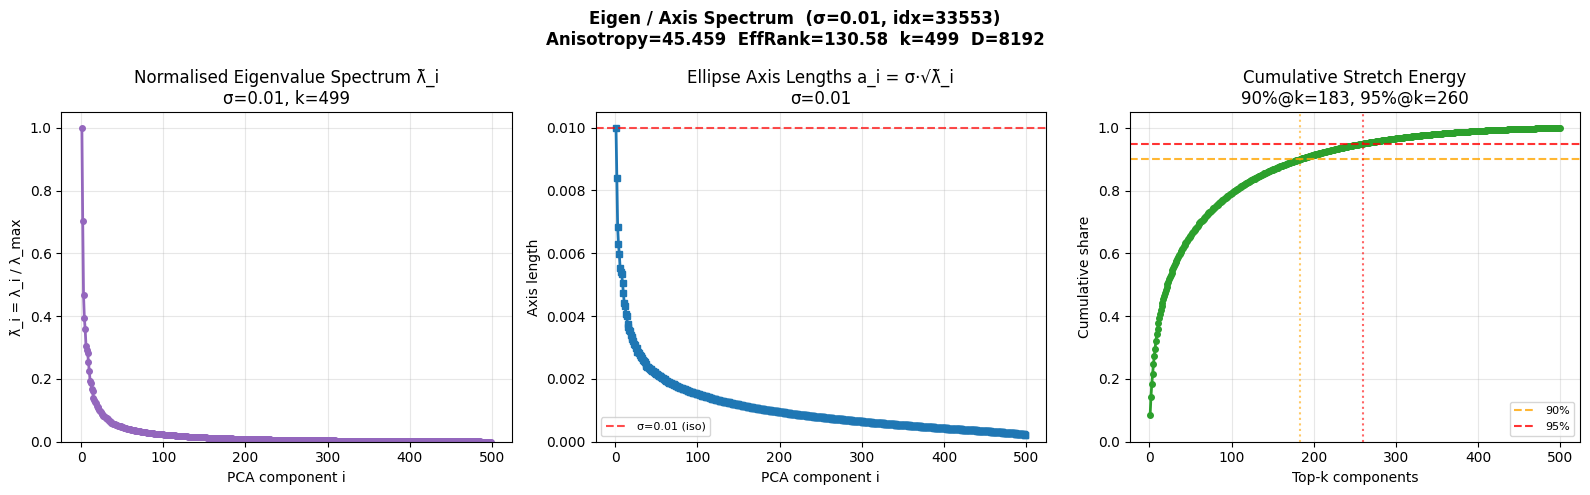

Saved: section_d_eigen_spectrum_sigma0.01.png


In [11]:
# ─── D3: Axis/Eigenvalue spectrum — pick one sample and show spectrum ────────
# Uses the stored axis_lengths / eigenvalues_norm from the first available result
SPEC_SIGMA = 0.010   # change to any σ you have data for
SPEC_N     = 500

spec_results = grid.get((SPEC_SIGMA, SPEC_N)) or grid.get((SPEC_SIGMA, 1000)) or []
# Find a result with eigenvalues_norm stored
spec_result = next(
    (r for r in spec_results if r.get('volumes', {}).get('eigenvalues_norm')),
    None
)

if spec_result is None:
    print(f"No eigenvalues_norm found for σ={SPEC_SIGMA}, N={SPEC_N}.")
    print("Available grid keys:", sorted(grid.keys())[:10])
else:
    vol = spec_result['volumes']
    evals_norm = np.asarray(vol['eigenvalues_norm'], dtype=np.float64)
    axes_spec  = np.asarray(vol.get('axis_lengths', _axis_lengths(SPEC_SIGMA, evals_norm)), dtype=np.float64)
    cum_energy = np.asarray(vol.get('cumulative_stretch_energy',
                                     np.cumsum(evals_norm) / max(evals_norm.sum(), 1e-30)),
                            dtype=np.float64)

    k = len(evals_norm)
    x = np.arange(1, k + 1)

    fig, axes_plot = plt.subplots(1, 3, figsize=(16, 5))

    # Panel 1: normalised eigenvalue spectrum
    ax = axes_plot[0]
    ax.plot(x, evals_norm, 'o-', lw=2, color='tab:purple', markersize=4)
    ax.set_title(f'Normalised Eigenvalue Spectrum λ̃_i\nσ={SPEC_SIGMA}, k={k}')
    ax.set_xlabel('PCA component i'); ax.set_ylabel('λ̃_i = λ_i / λ_max')
    ax.set_ylim(bottom=0); ax.grid(alpha=0.3)

    # Panel 2: axis lengths a_i = σ · √λ̃_i
    ax = axes_plot[1]
    ax.plot(x, axes_spec, 's-', lw=2, color='tab:blue', markersize=4)
    ax.axhline(SPEC_SIGMA, color='red', ls='--', alpha=0.7, label=f'σ={SPEC_SIGMA} (iso)')
    ax.set_title(f'Ellipse Axis Lengths a_i = σ·√λ̃_i\nσ={SPEC_SIGMA}')
    ax.set_xlabel('PCA component i'); ax.set_ylabel('Axis length')
    ax.set_ylim(bottom=0); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    # Panel 3: cumulative stretch energy
    ax = axes_plot[2]
    ax.plot(x, cum_energy, 'o-', lw=2, color='tab:green', markersize=4)
    ax.axhline(0.90, color='orange', ls='--', alpha=0.8, label='90%')
    ax.axhline(0.95, color='red',    ls='--', alpha=0.8, label='95%')
    idx_90 = int(np.searchsorted(cum_energy, 0.90)) + 1
    idx_95 = int(np.searchsorted(cum_energy, 0.95)) + 1
    ax.axvline(idx_90, color='orange', ls=':', alpha=0.6)
    ax.axvline(idx_95, color='red',    ls=':', alpha=0.6)
    ax.set_title(f'Cumulative Stretch Energy\n90%@k={idx_90}, 95%@k={idx_95}')
    ax.set_xlabel('Top-k components'); ax.set_ylabel('Cumulative share')
    ax.set_ylim(0, 1.05); ax.legend(fontsize=8); ax.grid(alpha=0.3)

    plt.suptitle(
        f'Eigen / Axis Spectrum  (σ={SPEC_SIGMA}, idx={spec_result["idx"]})\n'
        f'Anisotropy={vol.get("anisotropy_ratio", "N/A"):.3f}  '
        f'EffRank={vol.get("eigen_effective_rank", "N/A"):.2f}  '
        f'k={k}  D={vol.get("D", "?")}',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(f'section_d_eigen_spectrum_sigma{SPEC_SIGMA}.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: section_d_eigen_spectrum_sigma{SPEC_SIGMA}.png")


## Section E: Sample Circle + Ellipse Visualization\nFor a chosen sample, reconstruct its local PCA 2D neighborhood and overlay:\n- **Dashed circle** = isotropic ball of radius σ\n- **Solid ellipse** = manifold-aware region with axis lengths a_i = σ·√λ̃_i\n\nShows all 20 fine sigmas (0.01→0.25) **and** the 5 coarse sigmas (0.25, 0.50, 0.70, 0.75, 1.00).

In [17]:
# ============================================================
# SECTION E1: Re-synthesise 2D neighborhood from stored concept vectors
# (no ANNOY index needed — uses val/train tensors already in memory)
# ============================================================
import torch
import numpy as np
from sklearn.decomposition import PCA
from pathlib import Path

DATA_BASE_E = Path("..") / "smoothing_data"
# VIZ_SAMPLE_SIGMAS = [0.25, 0.50, 0.70, 0.75, 1.00]   # coarse set for overlay
VIZ_SAMPLE_SIGMAS = [0.010, 0.038, 0.066 ,0.094 ,0.121, 0.149 ,0.177, 0.204, 0.232 ,0.250] 
K_VIZ = 500          # how many neighbors to fetch via brute-force

# Load concept vectors if not already in memory
def _load_cv(name):
    p = DATA_BASE_E / f"concept_vectors_imagenet_{name}.pt"
    if p.exists():
        return torch.load(p, map_location='cpu')
    return None

_train_cv = _load_cv('train')
_val_cv   = _load_cv('val')

if _train_cv is None or _val_cv is None:
    print("concept_vectors not found — skipping Section E.")
    _section_e_ok = False
else:
    _section_e_ok = True
    print(f"Train: {_train_cv.shape}, Val: {_val_cv.shape}")


: 

In [ ]:
# ─── E2: Build 2D neighborhood + draw circles & ellipses ────────────────────
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

FINE_VIZ_SIGMAS   = [0.010, 0.023, 0.035, 0.048, 0.061, 0.073, 0.086, 0.099,
                     0.111, 0.124, 0.136, 0.149, 0.162, 0.174, 0.187, 0.200,
                     0.212, 0.225, 0.237, 0.250]
COARSE_VIZ_SIGMAS = [0.25, 0.50, 0.70, 0.75, 1.00]

SIGMA_PALETTE = plt.cm.plasma(np.linspace(0.10, 0.90, max(len(FINE_VIZ_SIGMAS), len(COARSE_VIZ_SIGMAS))))
SCATTER_COLOR = "#d0d0d0"
ANCHOR_COLOR  = "#f5c518"

def make_circle_ellipse_fig(target_idx, train_cv_t, val_cv_t, sigmas_to_plot,
                             k_neighbors=K_VIZ, pca_components=10,
                             title_prefix=""):
    """
    Build 3-panel figure (full / mid-zoom / tight-zoom) for one val sample.
    Overlays isotropic circles (dashed) and manifold ellipses (solid)
    for all sigmas in sigmas_to_plot.
    """
    anchor_vec = val_cv_t[target_idx].numpy().astype(np.float32)
    train_np   = train_cv_t.numpy().astype(np.float32)

    # Brute-force KNN (cosine → L2 in normalized space; or plain L2)
    dists  = np.linalg.norm(train_np - anchor_vec, axis=1)
    nn_idx = np.argsort(dists)[:k_neighbors]
    nb_vecs = train_np[nn_idx]

    local_mean  = nb_vecs.mean(axis=0)
    nb_centered = nb_vecs  - local_mean
    anch_centered = anchor_vec - local_mean

    n_comp = int(min(pca_components, nb_centered.shape[0], nb_centered.shape[1]))
    pca = PCA(n_components=n_comp, svd_solver='randomized', random_state=0)
    pca.fit(nb_centered)

    evals     = np.maximum(pca.explained_variance_, 1e-12).astype(np.float64)
    evals_norm = (evals / evals.max()).astype(np.float64)

    nb_2d     = nb_centered   @ pca.components_.T[:, :2]
    anchor_2d = anch_centered @ pca.components_.T[:, :2]

    pc1_std   = float(np.std(nb_2d[:, 0]))
    pc1_range = float(nb_2d[:, 0].max() - nb_2d[:, 0].min())
    max_sigma = float(max(sigmas_to_plot)) if sigmas_to_plot else 1.0
    zoom_mid   = max(0.10 * pc1_range, max_sigma * 1.5)
    zoom_tight = 3.0 * max_sigma

    zoom_configs = [
        (None,       f"[A] Full cloud  |  PC1 std={pc1_std:.3f}"),
        (zoom_mid,   f"[B] Mid-zoom ±{zoom_mid:.3f}"),
        (zoom_tight, f"[C] Tight zoom ±{zoom_tight:.3f}  (=3×max σ)"),
    ]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), facecolor='white')
    fig.suptitle(
        f"{title_prefix}Circle + Ellipse — val idx={target_idx}  k={k_neighbors}\n"
        f"σ list = {[round(s,3) for s in sigmas_to_plot]}",
        fontsize=10, fontweight='bold', y=1.04,
    )

    for ax, (zr, panel_title) in zip(axes, zoom_configs):
        ax.scatter(nb_2d[:, 0], nb_2d[:, 1], c=SCATTER_COLOR, s=5, alpha=0.25,
                   linewidths=0, zorder=1)

        for si, sigma in enumerate(sigmas_to_plot):
            color = SIGMA_PALETTE[si % len(SIGMA_PALETTE)]
            alpha = 0.85 - si * 0.02
            a0 = sigma * float(np.sqrt(evals_norm[0]))
            a1 = sigma * float(np.sqrt(evals_norm[1])) if len(evals_norm) > 1 else a0

            ax.add_patch(plt.Circle(
                (float(anchor_2d[0]), float(anchor_2d[1])), float(sigma),
                fill=False, edgecolor=color, linewidth=1.6,
                linestyle=(0, (4, 2)), alpha=alpha, zorder=4,
            ))
            ax.add_patch(Ellipse(
                (float(anchor_2d[0]), float(anchor_2d[1])),
                width=2*a0, height=2*a1,
                fill=False, edgecolor=color, linewidth=1.6,
                linestyle='solid', alpha=alpha, zorder=4,
            ))

        ax.scatter(float(anchor_2d[0]), float(anchor_2d[1]),
                   c=ANCHOR_COLOR, s=180, marker='*', edgecolors='#444',
                   linewidths=0.8, zorder=6)

        if zr is not None:
            ax.set_xlim(float(anchor_2d[0]) - zr, float(anchor_2d[0]) + zr)
            ax.set_ylim(float(anchor_2d[1]) - zr, float(anchor_2d[1]) + zr)

        ax.set_aspect('equal')
        ax.set_title(panel_title, fontsize=8.5)
        ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
        ax.grid(alpha=0.3)

    # Legend
    legend_handles = [
        plt.Line2D([0],[0], color='gray', lw=1.6, linestyle=(0,(4,2)), label='Iso circle (dashed)'),
        plt.Line2D([0],[0], color='gray', lw=1.6, linestyle='solid',   label='Mani ellipse (solid)'),
        plt.Line2D([0],[0], marker='*', color='w', markerfacecolor=ANCHOR_COLOR,
                   markeredgecolor='#444', markersize=10, label='Anchor'),
    ]
    for si, sigma in enumerate(sigmas_to_plot):
        color = SIGMA_PALETTE[si % len(SIGMA_PALETTE)]
        legend_handles.append(plt.Line2D([0],[0], color=color, lw=1.5,
                                          linestyle='solid', label=f'σ={sigma}'))
    fig.legend(handles=legend_handles, loc='lower center',
               ncol=min(len(sigmas_to_plot)+3, 8), fontsize=7,
               frameon=True, framealpha=0.95, edgecolor='#ccc',
               bbox_to_anchor=(0.5, -0.05))
    plt.tight_layout(rect=[0, 0.09, 1, 1])
    return fig

if _section_e_ok:
    # pick a sample from first available result
    _sample_idx = next(iter(grid.values()))[0]['idx'] if grid else 0
    print(f"Visualising val idx={_sample_idx}")

    fig_fine = make_circle_ellipse_fig(
        _sample_idx, _train_cv, _val_cv,
        FINE_VIZ_SIGMAS, title_prefix="Fine σ (0.01→0.25)  ")
    fig_fine.savefig(f'section_e_circle_ellipse_fine_idx{_sample_idx}.png',
                     dpi=170, bbox_inches='tight')
    plt.show()

    fig_coarse = make_circle_ellipse_fig(
        _sample_idx, _train_cv, _val_cv,
        COARSE_VIZ_SIGMAS, title_prefix="Coarse σ  ")
    fig_coarse.savefig(f'section_e_circle_ellipse_coarse_idx{_sample_idx}.png',
                       dpi=170, bbox_inches='tight')
    plt.show()
    print(f"Saved circle/ellipse figures for idx={_sample_idx}")


In [ ]:
# ─── E3: Multi-sample gallery — first N_GALLERY val samples ──────────────────
N_GALLERY = 5      # how many samples to show

if _section_e_ok:
    # collect N_GALLERY distinct val indices from stored results (or just 0..N_GALLERY)
    seen_indices = []
    for res_list in grid.values():
        for r in res_list:
            if r['idx'] not in seen_indices:
                seen_indices.append(r['idx'])
            if len(seen_indices) >= N_GALLERY:
                break
        if len(seen_indices) >= N_GALLERY:
            break
    if not seen_indices:
        seen_indices = list(range(N_GALLERY))

    for s_idx in seen_indices:
        print(f"\n─── val idx={s_idx} ─────────────────────────────────────────")
        fig = make_circle_ellipse_fig(
            s_idx, _train_cv, _val_cv,
            COARSE_VIZ_SIGMAS,
            title_prefix=f"Sample idx={s_idx}  "
        )
        fname = f'section_e_gallery_idx{s_idx}.png'
        fig.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()
        print(f"  Saved: {fname}")
